# The Shell: Where Your Files Actually Are

**Strand:** Tooling — lesson 1 of 6 · **Contact time:** 2 hours · **Kernel:** `ai-diploma`

## 📚 Learning Objectives

By completing this notebook, you will:

- Say where you are with `pwd`, and explain why a notebook's working directory is almost never
  the folder you think it is
- Write **absolute** and **relative** paths correctly, including paths that contain spaces
- List, copy, move and delete files from the shell — safely, inside a scratch directory this
  notebook creates and destroys
- Name many files at once with **wildcards**
- Chain commands with **pipes** and send output to files with **redirection**
- Search a real 421-notebook repository with **`grep`** and **`find`**
- Read **exit codes**, and explain why every automated gate in this repository is built on them
- Diagnose a portability bug that actually shipped in this repository — and say why `grep` could
  not have found it

## 🔗 Where this fits

**Builds on:** nothing. This is the first thing. You need no Python and no prior course to run it.

**Used later in:** every remaining lesson of this Tooling strand — lesson 02 on git, lesson 03 on
environments and dependencies, and lesson 06 on handing over a repository all assume you can move
around a filesystem without thinking about it. A virtual environment is a directory, a git
repository is a directory, and a code review is reading files you did not write. It is also the
missing prerequisite behind
`Course 04/unit1-regression-algorithms/examples/01_data_loading_exploration.ipynb`, where a shared
loader replaced hand-written file paths, and behind every script in `tools/verify/`, which decides
pass or fail purely by exit code.

---

## 🎯 The bug that `grep` could not find

On **31 August 2026** a commit landed in this repository with the message:

> `fix(portability): remove legacy hard-coded dataset paths left beside the loader calls`
>
> *Three Course 04 notebooks kept an older cell that built the path itself
> (`REPO / 'Course 04' / 'datasets' / 'raw' / ...`), so they still died on a fresh clone.*

Three notebooks had lines like this one:

```python
CSV = REPO / "Course 04" / "datasets" / "raw" / "border_crossing_data.csv"
raw = pd.read_csv(CSV, usecols=["Port Code", "State", "Border", "Date", "Measure", "Value"])
```

That code is not obviously wrong. `REPO` was even computed properly, by walking up the directory
tree. It ran perfectly on the machine it was written on. It ran perfectly in review. And on any
other computer in the world it raised `FileNotFoundError`, because
`Course 04/datasets/raw/border_crossing_data.csv` is a 35 MB file that **git does not track** —
it is excluded in `.gitignore`. A fresh clone gets the folder and not the file.

Now the part this lesson is really about. Suppose you had been asked to audit the repository for
exactly this class of bug. The obvious command is:

```bash
grep -rl --include="*.ipynb" "/Users/" Course\ ??
```

You will run it in a few minutes. It returns **61 notebooks** — and **not one of them** is one of
the three that were broken. Every single one of those 61 is a false positive, and all three real
bugs are invisible to it, because the broken path was never written down as a literal string. It
was *assembled* at runtime out of pieces.

By the end of this notebook you will have run that audit yourself, seen exactly why it fails, and
found the three real notebooks with a different tool.

---

## 📥 Inputs & 📤 Outputs

**Inputs:** this repository, exactly as it sits on your disk. No dataset is downloaded, no model is
trained, and nothing needs a network connection. Two things are read that are not ordinary files:

- the repository's own **git history**, for the commit above — guarded, so that if you got this code
  as a ZIP rather than a clone those cells say so and move on;
- a **scratch directory** created in your system temp folder by the setup cell below.

**Outputs:** printed shell output, one two-panel figure, and a scratch directory that the last cell
deletes. **Nothing in this repository is modified by this notebook.** Every command that creates,
copies, moves or deletes a file operates inside the scratch directory.

---

In [1]:
# WHAT: find this repository's root folder, remember it, and make a private scratch directory.
# WHY:  every later cell needs two paths - the repo (which we only ever READ) and a throwaway
#       folder (the only place we are allowed to WRITE). We do not type either as a literal,
#       because a literal path is exactly the bug this lesson is about: it would work here and
#       fail on your classmate's laptop. We compute both instead.
import os
import shutil
import subprocess
import tempfile
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    """Walk UP from `start` until we hit a folder that looks like this repository.

    'Looks like' means: it contains a 'tools' folder and at least one 'Course NN' folder.
    Walking up is how git, npm, pytest and every other tool finds its own root - the current
    directory is untrustworthy, but the shape of the tree above you is not.
    """
    for candidate in [start, *start.parents]:
        if (candidate / "tools").is_dir() and any(candidate.glob("Course [0-9][0-9]")):
            return candidate
    raise RuntimeError(f"No repository root found above {start}")

REPO = find_repo_root(Path.cwd().resolve())

# SCRATCH lives in the operating system's temp area, NOT inside the repository. Anything we
# break in here is invisible to git and gone by the end of the notebook.
SCRATCH = Path(tempfile.mkdtemp(prefix="shell_lesson_"))

# Exporting them as environment variables is what lets the %%bash cells below see them: a
# %%bash cell starts a brand-new shell process, and a child process inherits os.environ.
os.environ["REPO"] = str(REPO)
os.environ["SCRATCH"] = str(SCRATCH)

# Housekeeping: some machines ask `ls` to colour its output, which fills a saved notebook
# with unreadable escape codes. Turn that off for the shells we are about to start.
for _colour_var in ("CLICOLOR", "CLICOLOR_FORCE", "LS_COLORS", "LSCOLORS"):
    os.environ.pop(_colour_var, None)

print("REPO    =", REPO)
print("SCRATCH =", SCRATCH)
print("cwd     =", Path.cwd())

REPO    = /Users/abdullah/Downloads/AI Diploma
SCRATCH = /var/folders/7n/l2c2z2x57871xg4f_0drsv1m0000gn/T/shell_lesson_uua2qsdi
cwd     = /Users/abdullah/Downloads/AI Diploma/TOOLING/examples


## 1. Where am I? — and why the answer surprises you

A shell always has a **current working directory**. Every command you type that does not begin with
`/` is interpreted relative to it. `pwd` ("print working directory") tells you what it is.

A notebook has one too, and here is the thing nobody tells you: **it is the folder the notebook file
lives in, not the folder you opened Jupyter from, and not the root of the project.** Open the same
notebook through JupyterLab, through VS Code, through `nbconvert`, or on Colab and you can get four
different working directories for the same file.

That is why `pd.read_csv("../../datasets/raw/montgomery_911_calls.csv")` is a bug rather than a
path. It encodes a guess about how deep you are, and the guess is only right in one of those four
cases.

Run the next cell and read the lines it prints.

In [2]:
# WHAT: prove what this notebook's working directory actually is, and show a relative path
#       succeeding and failing for the same file.
# WHY:  "it works on my machine" almost always means "my working directory happened to match".
#       Seeing the two lookups side by side is the fastest cure.
here = Path.cwd()
print("This notebook's working directory :", here)
print("Its position inside the repo      :", here.relative_to(REPO))
print("Depth below the repo root         :", len(here.relative_to(REPO).parts), "folders")
print()

# The repository's README.md sits at the ROOT. Try to reach it two ways.
for attempt in ["README.md", "../../README.md"]:
    p = Path(attempt)
    verdict = "FOUND" if p.is_file() else "not found"
    print(f"  open({attempt!r:20}) -> {verdict}")

print()
# The version that never breaks: build the path from a root you DISCOVERED, not from a guess
# about how many '..' you need.
print(f"  open(REPO / 'README.md')     -> {'FOUND' if (REPO / 'README.md').is_file() else 'not found'}")
print(f"  ...which resolves to           {REPO / 'README.md'}")

This notebook's working directory : /Users/abdullah/Downloads/AI Diploma/TOOLING/examples
Its position inside the repo      : TOOLING/examples
Depth below the repo root         : 2 folders

  open('README.md'         ) -> not found
  open('../../README.md'   ) -> FOUND

  open(REPO / 'README.md')     -> FOUND
  ...which resolves to           /Users/abdullah/Downloads/AI Diploma/README.md


### 👁️ Read the output

Three facts, and one rule.

1. **The working directory is `TOOLING/examples`,** two folders below the repository root — because
   that is where this `.ipynb` file lives. Nobody chose it; the tool that launched the kernel did.
2. **`README.md` is not found.** There is no `README.md` in `TOOLING/examples`. The name is
   perfectly valid and resolves to a file that does not exist.
3. **`../../README.md` is found**, because from `TOOLING/examples`, two hops up is the root.

The rule: **`../../` is a guess about your own depth.** Move this notebook one folder deeper, or
open it from a different tool, and hop count 2 becomes wrong while the code stays unchanged — so it
fails at load time, on someone else's computer, with a message about a file rather than about a
path. `REPO / "README.md"` cannot fail that way, because `REPO` was *found* rather than assumed.
That is exactly what `tools/data.py` does for datasets in this repository, and it is why
`load("titanic")` takes no path at all.

## 2. `pwd`, `ls`, `cd` — and the one thing that does not persist

From here on we use real shell commands. The `%%bash` line at the top of a cell means *"send this
whole cell to a bash shell and show me exactly what it prints"*. It is not a simulation.

Three commands do almost all the navigating:

| command | reads as | what it does |
|---|---|---|
| `pwd` | print working directory | where am I |
| `ls` | list | what is here |
| `cd` | change directory | go somewhere else |

And five path fragments do almost all the pointing:

| fragment | means |
|---|---|
| `/` | the very top of the filesystem — an **absolute** path starts here |
| `.` | the directory I am in now |
| `..` | the directory one level up |
| `~` | my home directory |
| `-` | with `cd`, the directory I was in before |

**Watch for the trap in the next two cells.** The first ends with `cd ..`. The second asks where we
are.

In [3]:
%%bash
# WHAT: show where a fresh bash shell starts, list what is there, then move up two levels.
# WHY:  this is the loop you will run a hundred times a day - look, move, look again.

echo "1. where the shell starts, and which process is answering:"
pwd
echo "   this shell's process id: $$"

echo
echo "2. what is in here (ls -1 prints one name per line):"
ls -1

echo
echo "3. move up one level with 'cd ..' and look again:"
cd ..
pwd

echo
echo "4. and up once more - this is the repository root:"
cd ..
pwd

echo
echo "5. the first six things at the root:"
ls -1 | head -6

1. where the shell starts, and which process is answering:
/Users/abdullah/Downloads/AI Diploma/TOOL

ING/examples


   this shell's process id: 41118



2. what is in here (ls -1 prints one name per line):


01_shell_and_filesystem.ipynb
02_git_for_one_and_for_two.ipynb
03_environments_and_dependencies.ipyn

...

nb



3. move up one level with 'cd ..' and look again:
/Users/abdullah/Downloads/AI Diploma/TOOLING

4. 

and up once more - this is the repository root:
/Users/abdullah/Downloads/AI Diploma

5. the first s

ix things at the root:


28
AGENTS.md
Course 01
Course 02
Course 03
Course 04


In [4]:
%%bash
# WHAT: ask a SECOND bash cell where it is, immediately after the first one moved two levels up.
# WHY:  if you expect to still be at the repository root, this cell is about to correct you.

pwd
echo "   ^ not the repository root. The previous cell's 'cd' is gone."
echo
echo "The reason, in one line: this is a different process."
echo "   this shell's process id: $$"

/Users/abdullah/Downloads/AI Diploma/TOOLING/examples


   ^ not the repository root. The previous cell's 'cd' is gone.

The reason, in one line: this is a 

different process.
   this shell's process id: 41122


### 👁️ Read the output

The first cell walked from `TOOLING/examples` up to the repository root. The second cell starts back
in `TOOLING/examples` — the walk was undone.

**Nothing was undone. A different shell answered.** Each `%%bash` cell launches a brand-new bash
process, which inherits its starting directory from the kernel and then dies at the end of the cell,
taking its `cd` with it. Both cells printed `$$`, the process id of the shell answering, and the
two numbers are different — that is the proof, and it is two shells, not one shell that forgot.

This is not a Jupyter quirk. It is the rule everywhere: **a child process cannot change its parent's
working directory.** It is why a shell script that ends in `cd /somewhere` leaves your terminal
exactly where it was, and why `source script.sh` exists as a way to run a script *in* your current
shell instead of in a child.

The working consequence for this notebook: **every `%%bash` cell below starts by `cd`-ing where it
needs to be.** We can do that because the setup cell put the two paths into the environment, and
environment variables *are* inherited by child processes — which is exactly why `$REPO` and
`$SCRATCH` work in a shell that has never heard of the Python variables `REPO` and `SCRATCH`.

## 3. Wildcards — naming a hundred files without typing a hundred names

The shell expands wildcards **before** the command runs. When you type `ls *.ipynb`, `ls` never sees
a `*`; bash replaces it with the list of matching filenames first. This is called *globbing*, and
the command being run has no idea it happened.

| pattern | matches |
|---|---|
| `*` | any run of characters, including none — but **not** a `/` |
| `?` | exactly one character |
| `[0-9]`, `[abc]` | one character from the set |
| `{a,b}` | brace expansion: the whole word, once per alternative — not a glob, it never looks at the disk |

**And the trap that will bite you in this repository specifically:** the course folders are called
`Course 01`, with a space. `ls Course 01/...` asks for two separate things, `Course` and `01/...`,
and both fail. You must quote the space or escape it: `"Course 01"/...` or `Course\ 01/...`. Notice
that quoting only *part* of a word is legal and useful — in `"Course "??` the quoted half is literal
and the `??` still globs.

In [5]:
%%bash
# WHAT: use wildcards to select real notebooks from this repository, six different ways.
# WHY:  every audit, every batch rename and every "run all the tests in this folder" starts here.
cd "$REPO"

echo "A. every example notebook in Course 04, all five units, counted:"
ls "Course 04"/unit*/examples/*.ipynb | wc -l

echo
echo "B. the first three of them, so you can see the shape of the names:"
ls "Course 04"/unit*/examples/*.ipynb | head -3

echo
echo "C. '?' matches exactly one character - here, the unit number:"
ls -d "Course 04"/unit?-*

echo
echo "D. a character class picks lessons 01 and 02 out of every unit of Course 04:"
ls "Course 04"/unit*/examples/0[12]_*.ipynb | wc -l

echo
echo "E. partial quoting: the space is literal, the '??' still globs:"
ls -d "Course "?? | tr '\n' ' '
echo

echo
echo "F. brace expansion is NOT a glob - it just multiplies the word out:"
echo Course\ 0{1,2,3}
echo "   (it printed all three even though it never looked at the disk)"

echo
echo "G. quoting the WHOLE pattern disables globbing - a classic beginner failure:"
ls "Course 04/unit*/examples/*.ipynb" 2>&1 | head -1

A. every example notebook in Course 04, all five units, counted:


      20


B. the first three of them, so you can see the shape of the names:


Course 04/unit1-regression-algorithms/examples/01_data_loading_exploration.ipynb
Course 04/unit1-reg

ression-algorithms/examples/02_data_cleaning.ipynb
Course 04/unit1-regression-algorithms/examples/03

...

Course 11 Course 12 



F. brace expansion is NOT a glob - it just multiplies the word out:
Course 01 Course 02 Course 03


   (it printed all three even though it never looked at the disk)

G. quoting the WHOLE pattern disa

bles globbing - a classic beginner failure:


ls: Course 04/unit*/examples/*.ipynb: No such file or directory


### 👁️ Read the output

**A** found **20** example notebooks in Course 04 with a single line. `unit*` matched five unit
folders and `*.ipynb` matched the notebooks inside each. Note that `*` did not cross a `/` — that is
why `unit*/examples/*` needs both stars.

**C** shows `?` matching one character: `unit?-*` picks up `unit1-regression-algorithms` through
`unit5-model-selection`, but would not match a hypothetical `unit10-`.

**F** is the important one. `echo Course\ 0{1,2,3}` printed `Course 01 Course 02 Course 03` — and it
would print exactly that on an empty disk, because brace expansion is pure text substitution. `*` and
`?` ask the filesystem what exists; `{}` does not. That difference matters the moment you write
`mv Course\ 0{1,2}` and discover you have just renamed something.

**E and G together are the quoting rule.** `"Course 04"/unit*/...` works: the quotes protect the
space, end at the closing quote, and the glob outside them still expands. Quoting the whole path
(**G**) disables globbing entirely and produces *no such file or directory*, because the shell then
looks for one file whose name literally contains an asterisk. **Quote the space, not the pattern.**

## 4. Pipes and redirection — building a sentence out of small commands

This is the single idea that makes the shell worth learning. Each of these commands does one small
thing and reads from *standard input*, so you can wire the output of one into the input of the next
with `|`. There is no library and no API; the interface between any two of these programs is plain
text.

| operator | meaning |
|---|---|
| `a \| b` | send `a`'s output into `b`'s input |
| `> file` | send output to a file, **replacing** it |
| `>> file` | send output to a file, **appending** |
| `2> file` | send *errors* (stream 2) to a file |
| `2>/dev/null` | throw errors away |
| `< file` | read input from a file |

The workhorses: `wc -l` counts lines, `sort` sorts, `uniq -c` counts adjacent duplicates, `head` and
`tail` take the ends, `cut` and `sed` reshape each line, `tr` translates characters.

We are going to build one pipeline in four visible stages — a census of every example notebook in
the diploma, grouped by course.

In [6]:
%%bash
# WHAT: build one pipeline in four visible stages, then redirect the finished result to a file.
# WHY:  nobody writes a six-stage pipeline in one go. You add one stage, look, add the next.
cd "$REPO"

echo "STAGE 1 - just find the files. How many example notebooks exist in the whole diploma?"
find "Course "?? -type f -name "*.ipynb" -path "*/examples/*" | wc -l

echo
echo "STAGE 2 - look at one line of that output, to see what we have to work with:"
find "Course "?? -type f -name "*.ipynb" -path "*/examples/*" | head -1

echo
echo "STAGE 3 - keep only the course name: sed deletes everything from the first '/' onwards."
find "Course "?? -type f -name "*.ipynb" -path "*/examples/*" | sed -E 's|/.*||' | head -3

echo
echo "STAGE 4 - sort so identical names sit together, then 'uniq -c' counts each run:"
find "Course "?? -type f -name "*.ipynb" -path "*/examples/*" \
  | sed -E 's|/.*||' | sort | uniq -c | sort -rn

echo
echo "Now REDIRECT the same pipeline into a file in the scratch directory, and count its lines:"
find "Course "?? -type f -name "*.ipynb" -path "*/examples/*" \
  | sed -E 's|/.*||' | sort | uniq -c | sort -rn > "$SCRATCH/census.txt"
wc -l < "$SCRATCH/census.txt"

echo
echo "APPEND a footer with '>>' rather than '>', which would have erased the file:"
echo "--- generated by lesson 01 ---" >> "$SCRATCH/census.txt"
tail -2 "$SCRATCH/census.txt"

echo
echo "And errors are a SEPARATE stream. Ask for a folder that does not exist:"
ls "Course 99" 2>/dev/null | wc -l
echo "   ^ zero lines of output and no error on screen, because stream 2 went to /dev/null."
echo "   Note what did NOT happen: the pipeline did not stop. Silencing errors is a choice you"
echo "   make on purpose, and section 9 shows how to notice them anyway."

STAGE 1 - just find the files. How many example notebooks exist in the whole diploma?


     328



STAGE 2 - look at one line of that output, to see what we have to work with:


Course 01/unit5-generative-ai-intro/examples/01_generative_ai_introduction.ipynb


STAGE 3 - keep only the course name: sed deletes everything from the first '/' onwards.


...


And errors are a SEPARATE stream. Ask for a folder that does not exist:


       0


   ^ zero lines of output and no error on screen, because stream 2 went to /dev/null.


   Note what did NOT happen: the pipeline did not stop. Silencing errors is a choice you


   make on purpose, and section 9 shows how to notice them anyway.


### 👁️ Read the output

Stage 4 is a real answer to a real question — *how is teaching material distributed across this
diploma?* — and it took six words. Course 05 leads with 47 example notebooks; Course 12 has 6. If
you were handed this repository this morning, that census is a reasonable first thing to know, and
you now know it without opening a single file.

Three mechanics worth naming:

- **`sed -E 's|/.*||'`** deletes from the first `/` to the end of the line. The delimiter after `s`
  is normally `/`, but our data is full of slashes, so we used `|` instead. Any character works —
  a small kindness worth remembering every time your pattern is a path.
- **`sort` before `uniq -c` is not optional.** `uniq` only collapses *adjacent* duplicates. Drop the
  `sort` and you get nonsense that still looks plausible.
- **`wc -l < file` printed a bare number**, whereas `wc -l file` would have printed the number *and*
  the filename. Redirecting the input hides the name from `wc`, which is what you want when a later
  stage has to parse it.

And the last stanza: `2>/dev/null` discarded the error and the pipeline carried on cheerfully
reporting zero. That is fine when you meant it and dangerous when you did not — a nightly job that
silences stderr reports success forever. Section 9 is about the mechanism that lets you tell the
difference.

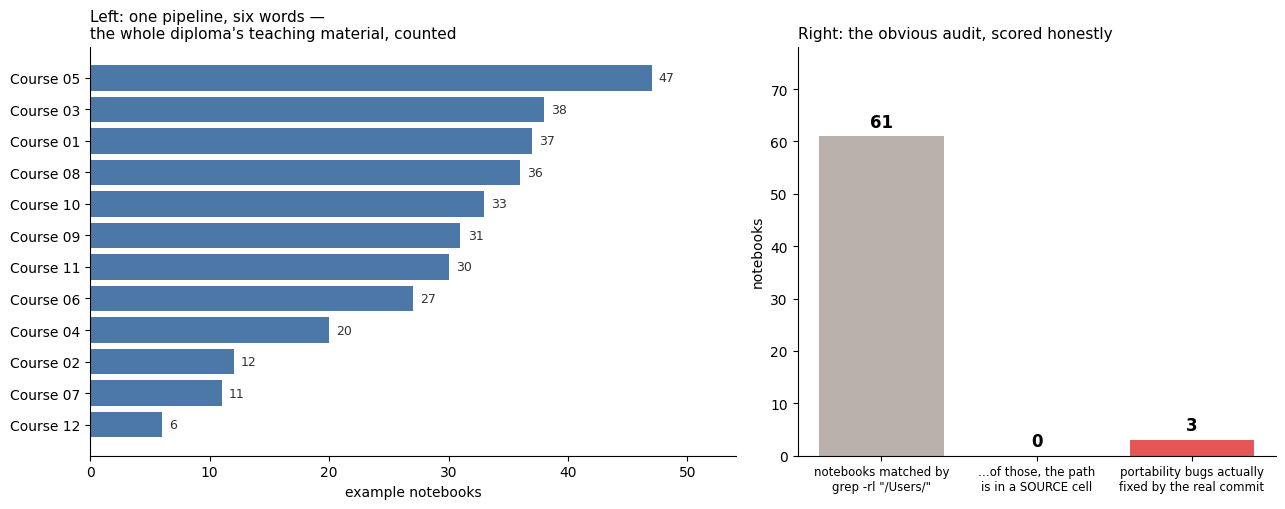

grep matched 61 notebooks; 0 have the string in a source cell, 61 only in stored outputs.
The commit that fixed the real problem touched 3 notebooks.


In [7]:
# WHAT: draw two panels. LEFT is the census pipeline you just ran, re-run through subprocess so
#       the bars are literally the text bash printed. RIGHT is the audit from the top of this
#       notebook, with all three of its numbers computed here rather than typed by hand.
# WHY:  the left panel is what the shell is FOR. The right panel is what this lesson is ABOUT -
#       a search that returns 61 confident results and zero correct ones.
import json
import matplotlib.pyplot as plt
import nbformat

def sh(cmd: str) -> str:
    """Run one bash command line in the repo root and hand back its stdout."""
    return subprocess.run(["bash", "-c", cmd], cwd=REPO,
                          capture_output=True, text=True).stdout

# --- LEFT: parse the census straight out of the pipeline's own output -------------------
census_cmd = (
    'find "Course "?? -type f -name "*.ipynb" -path "*/examples/*" '
    "| sed -E 's|/.*||' | sort | uniq -c | sort -n"
)
counts, names = [], []
for line in sh(census_cmd).strip().splitlines():
    n, course = line.split(None, 1)
    counts.append(int(n))
    names.append(course)

# --- RIGHT: run the naive audit, then check every hit with a notebook parser ------------
audit_cmd = 'grep -rl --include="*.ipynb" "/Users/" "Course "??'
hit_files = [f for f in sh(audit_cmd).splitlines() if f]

in_source = in_output_only = 0
for f in hit_files:
    nb_hit = nbformat.read(str(REPO / f), as_version=4)
    if any("/Users/" in c.source for c in nb_hit.cells):
        in_source += 1
    elif any("/Users/" in json.dumps(o) for c in nb_hit.cells for o in (c.get("outputs") or [])):
        in_output_only += 1

# The notebooks the real fix touched, counted from the git history itself.
bugs_cmd = (
    'SHA=$(git log --format=%H --grep="hard-coded dataset paths" -1) && '
    'git show "$SHA" --unified=0 -- "*.ipynb" '
    "| awk '/^\\+\\+\\+ b\\// { f=substr($0,7) } "
    "/^-/ && /raw/ && (/read_csv/ || /CSV =/) { print f }' "
    "| sort -u | wc -l"
)
real_bugs = int((sh(bugs_cmd).strip() or "0"))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.2),
                               gridspec_kw={"width_ratios": [1.35, 1]})

axL.barh(names, counts, color="#4C78A8")
for y, v in enumerate(counts):
    axL.text(v + 0.6, y, str(v), va="center", fontsize=9, color="#333333")
axL.set_xlim(0, max(counts) * 1.15)
axL.set_xlabel("example notebooks")
axL.set_title("Left: one pipeline, six words —\nthe whole diploma's teaching material, counted",
              fontsize=11, loc="left")
axL.spines[["top", "right"]].set_visible(False)

bars = [len(hit_files), in_source, real_bugs]
labels = ['notebooks matched by\ngrep -rl "/Users/"',
          "…of those, the path\nis in a SOURCE cell",
          "portability bugs actually\nfixed by the real commit"]
axR.bar(labels, bars, color=["#BAB0AC", "#4C78A8", "#E45756"])
for x, v in enumerate(bars):
    axR.text(x, v + max(bars) * 0.03, str(v), ha="center", fontsize=12, fontweight="bold")
axR.set_ylim(0, max(bars) * 1.28)
axR.set_ylabel("notebooks")
axR.set_title("Right: the obvious audit, scored honestly", fontsize=11, loc="left")
axR.tick_params(axis="x", labelsize=8.5)
axR.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"grep matched {len(hit_files)} notebooks; {in_source} have the string in a source cell, "
      f"{in_output_only} only in stored outputs.")
print(f"The commit that fixed the real problem touched {real_bugs} notebooks.")

### 👁️ Read the figure

**Left — this is what a pipeline buys you.** Twelve bars, one line of shell, no code written and no
file opened. Course 05 carries 47 example notebooks and Course 12 carries 6; whether that is the
right distribution is a curriculum question, but you can now *ask* it. That is the whole argument for
the shell: questions about a repository become one-liners instead of projects.

**Right — the same tool, used badly.** The grey bar is what `grep -rl "/Users/"` reported: **61**
notebooks. The blue bar is how many of those 61 have that string anywhere in a **code or markdown
cell**: **0**. All 61 matched inside *stored output* — text that a previous run happened to print and
that was saved into the file. The audit did not find 61 bugs. It found 61 saved messages.

The red bar is the number of notebooks the real fix actually touched: **3**. **The grey and red bars
do not overlap at all.** The audit's precision was zero and its recall was zero, and it looked
completely convincing.

Two lessons, and the second is the one to keep:

1. **`grep` searches text, not structure.** A `.ipynb` file is JSON, and inside that JSON the code a
   student runs and the output a previous run happened to print are just two kinds of string. `grep`
   cannot tell them apart. A tool that parses the notebook can — which is why the check in the cell
   above used `nbformat` for the second question and `grep` only for the first.
2. **The bug was invisible because it was assembled.**
   `REPO / "Course 04" / "datasets" / "raw" / "border_crossing_data.csv"` never contains the literal
   string you would search for. You cannot grep for a path the program computes. Section 6 finds
   those three notebooks anyway, with a tool that searches *changes* rather than *files*.

## 5. `grep` — searching a repository you have never seen

`grep` prints the lines of its input that match a pattern. The flags you will actually use:

| flag | effect |
|---|---|
| `-r` | recurse into directories |
| `-l` | print *filenames* only, not matching lines |
| `-c` | print a *count* per file |
| `-n` | show line numbers |
| `-h` | hide the filename prefix |
| `-i` | ignore case |
| `-v` | invert: print lines that do **not** match |
| `-o` | print only the matching part of the line |
| `-B 3` / `-A 3` | also show 3 lines before / after each match |
| `--include="*.py"` | only look inside files whose names match |
| `-m 1` | stop after the first match in each file |

`--include` is not a nicety. Without it, `grep -r` in this repository will happily read a 675 MB CSV
file looking for your pattern.

Now run the audit from the top of the notebook, and then take it apart.

In [8]:
%%bash
# WHAT: run the naive portability audit, then look closely at what it actually matched.
# WHY:  a count on its own is not evidence. Open a hit and read it before you believe a number.
cd "$REPO"

echo "A. the audit: notebooks under Course NN containing an absolute home-directory path"
grep -rl --include="*.ipynb" "/Users/" "Course "?? | wc -l

echo
echo "B. the three noisiest files, by number of matching lines (-c gives file:count):"
grep -rc --include="*.ipynb" "/Users/" "Course "?? | grep -v ":0$" | sort -t: -k2 -rn | head -3

echo
echo "C. now READ a match instead of counting it. Take the first file grep listed,"
echo "   and show the first hit with the three lines of JSON above it:"
F=$(grep -rl --include="*.ipynb" "/Users/" "Course "?? | head -1)
echo "   file: $F"
grep -n -m1 -B3 "/Users/" "$F" | cut -c1-185

echo
echo "D. what KIND of text are these lines? Pull the warning class out of every one:"
grep -rh --include="*.ipynb" "/Users/" "Course "?? \
  | grep -oE "[A-Za-z]+Warning" | sort | uniq -c | sort -rn | head -4

echo
echo "E. and where do the paths point? Group every matched path by its first few"
echo "   components and count them:"
grep -rho --include="*.ipynb" "/Users/[a-zA-Z0-9 _/.+-]*" "Course "?? \
  | cut -d/ -f1-5 | sort | uniq -c | sort -rn | head -5

echo
echo "F. the decisive question. Are any of the three genuinely broken notebooks"
echo "   in the list this audit produced?"
grep -rl --include="*.ipynb" "/Users/" "Course "?? > "$SCRATCH/audit_hits.txt"
B1="Course 04/unit2-regression-model-evaluation/enrichment/E10_conformal_prediction_in_twenty_lines.ipynb"
B2="Course 04/unit2-regression-model-evaluation/examples/02_bias_variance_learning_curves.ipynb"
B3="Course 04/unit5-model-selection/enrichment/E14_tabular_foundation_models_vs_boosting.ipynb"
for nb in "$B1" "$B2" "$B3"; do
  if grep -qxF "$nb" "$SCRATCH/audit_hits.txt"; then
    echo "   FOUND by the audit : $(basename "$nb")"
  else
    echo "   MISSED by the audit: $(basename "$nb")"
  fi
done

A. the audit: notebooks under Course NN containing an absolute home-directory path


      61



B. the three noisiest files, by number of matching lines (-c gives file:count):


Course 09/unit5-applications/exercises/01_rl_exercise.ipynb:17
Course 09/unit5-applications/examples

/08_goal_conditioned_rl.ipynb:17
Course 09/unit5-applications/examples/07_model_based_vs_model_free_

...


F. the decisive question. Are any of the three genuinely broken notebooks
   in the list this audit

 produced?


   MISSED by the audit: E10_conformal_prediction_in_twenty_lines.ipynb


   MISSED by the audit: 02_bias_variance_learning_curves.ipynb


   MISSED by the audit: E14_tabular_foundation_models_vs_boosting.ipynb


### 👁️ Read the output

**A** reproduces the number from the top of the notebook: **61** notebooks under `Course NN` contain
an absolute path into somebody's home directory.

**C is the discipline.** The hit is a line of JSON, and the three lines above it are
`"name": "stderr"`, `"output_type": "stream"`, `"text": [`. That is not code. It is a library warning
— in this run, a Keras `UserWarning` beginning *Do not pass an `input_shape`…* — that printed the
full path of the virtual environment it came from and was saved into the notebook the last time
somebody executed it. It never runs. It cannot fail on anybody's machine.

**D confirms it at scale.** Every matching line that names a warning class names one of three:
`UserWarning` (16), `ConvergenceWarning` (5) from scikit-learn, and `StarletteDeprecationWarning`
(4) from the web-framework lessons. These are library complaints, not code.

**E is the punchline.** Grouped by their first few components, the matched paths are overwhelmingly
`/Users/abdullah/Downloads/AI Diploma` — **627** of them: this repository's own location on the
author's disk, narrated back at us by warnings from the virtual environment inside it. **15** come
from a second environment, `/Users/abdullah/venvs/ai-diploma-tf`, the one the TensorFlow notebooks
use. A handful point into `/Users/abdullah/ai-diploma-portfolio` — an output folder from the Course 11
deployment lessons that never existed anywhere but one machine. And exactly **one** is `/Users/runner/work/pytorch` — the
working directory of a **GitHub Actions build machine**, compiled into a PyTorch warning string,
shipped inside a wheel, printed into a notebook here, and committed. Nobody on this project has ever
had a folder called `/Users/runner`.

**F settles it.** All three of the notebooks that actually broke come back `MISSED by the audit`.
The overlap between what the audit found and what was actually wrong is empty — the claim the
figure made, now run rather than asserted.

So the audit is not merely imprecise: it answered a different question than the one asked. It was
asked *"which notebooks will break on a fresh clone?"* and it answered *"which notebooks were last
executed on a Mac?"*. The one thing it did find is a small privacy leak — the author's username and
directory layout ship in the repository — which is worth fixing, and is not the bug we were hunting.

Two habits come out of this, and they are much of the difference between a junior and a senior
engineer reading an unfamiliar repository:

- **Never report a `grep -l` count as a finding.** Open one hit. Then open the one that looks least
  like the others. A count is a lead, not a result.
- **Match the tool to the file format.** For structured files — `.ipynb`, JSON, XML, HTML — a text
  search finds things that are technically present and semantically absent. Use a parser when that
  distinction matters, as the figure cell did.

One more warning, about scope. We searched `"Course "??` rather than the whole repository, and that
was deliberate: this notebook contains the string `/Users/` in its own source, because we typed the
pattern into it. **An auditor that scans itself always finds itself.** Scope your search, or be ready
to explain the hit.

## 6. Finding the bug that was never written down

The three broken notebooks cannot be found by searching for a string, because the string never
existed. But the *fix* exists, and it is in the repository's history. Searching history rather than
files is one of the highest-value moves available in a codebase you did not write.

`git log --grep=` searches commit **messages**. `git show` prints a commit's diff. Piped into `awk`,
that diff answers *"which files lost a line that looks like a hand-built dataset path?"* — the
question we could not ask of the working tree.

You will meet git properly later in this strand. Here it is just another program that prints text
into a pipe.

In [9]:
%%bash
# WHAT: find the fix in the git history, then extract the exact lines it deleted and which
#       notebooks they came from.
# WHY:  this is the search that works when grep fails. You cannot grep for a path the program
#       assembles at runtime, but you CAN grep the change that removed it.
cd "$REPO"

# Guard: a ZIP download has no history. Say so and stop, rather than printing a confusing error.
if ! git rev-parse --git-dir > /dev/null 2>&1; then
  echo "No git history here - this looks like a ZIP download rather than a clone. Skipping."
  exit 0
fi

SHA=$(git log --format=%H --grep="hard-coded dataset paths" -1)
echo "A. the commit, found by searching MESSAGES rather than files:"
git log --oneline -1 "$SHA"

echo
echo "B. the code lines it DELETED that build a dataset path by hand:"
git show "$SHA" -- "*.ipynb" | grep "^-" | grep "raw" | grep -E "read_csv|CSV =" | cut -c1-105

echo
echo "C. which notebooks those lines came from, and how many each lost:"
git show "$SHA" --unified=0 -- "*.ipynb" \
  | awk '/^\+\+\+ b\// { f=substr($0,7) } /^-/ && /raw/ && (/read_csv/ || /CSV =/) { print f }' \
  | sort | uniq -c

echo
echo "D. what replaced them:"
git show "$SHA" -- "*.ipynb" | grep "^+" | grep -E "= load\(" | cut -c1-105

echo
echo "E. the commit message says the stale cell sat 'alongside the new load() call'."
echo "   Count how often the loader is imported in one of those notebooks, before and after:"
NB="Course 04/unit2-regression-model-evaluation/enrichment/E10_conformal_prediction_in_twenty_lines.ipynb"
echo "   before the commit: $(git show "$SHA^:$NB" | grep -c 'tools.data')"
echo "   after  the commit: $(git show "$SHA:$NB"  | grep -c 'tools.data')"

A. the commit, found by searching MESSAGES rather than files:


9b6824f0 fix(portability): remove legacy hard-coded dataset paths left beside the loader calls



B. the code lines it DELETED that build a dataset path by hand:


-    "CSV = REPO / \"Course 04\" / \"datasets\" / \"raw\" / \"border_crossing_data.csv\"\n",
-    "r

aw = pd.read_csv(CSV, usecols=[\"Port Code\", \"State\", \"Border\", \"Date\", \"Measure\", \"Valu
-

...

n",
+    "full = load(\"montgomery_911_calls\", prefer=\"sample\",\n",



E. the commit message says the stale cell sat 'alongside the new load() call'.
   Count how often t

he loader is imported in one of those notebooks, before and after:


   before the commit: 0


   after  the commit: 2


### 👁️ Read the output

**B and C are the finding.** Five deleted lines, spread across exactly **three** notebooks:
`E10_conformal_prediction_in_twenty_lines.ipynb` lost three of them, and
`02_bias_variance_learning_curves.ipynb` and `E14_tabular_foundation_models_vs_boosting.ipynb` lost
one each. That is the red bar in the figure, and it took a pipeline of four programs — `git`, `grep`,
`awk`, `sort` — none of which knows anything about notebooks.

Notice the two *different* shapes of the same bug in **B**:

```
CSV   = REPO / "Course 04" / "datasets" / "raw" / "border_crossing_data.csv"   # absolute, assembled
calls = pd.read_csv("../../datasets/raw/montgomery_911_calls.csv", ...)        # relative, hops counted
```

The first computes a correct absolute path to a file a fresh clone does not have. The second guesses
its own depth *and* points at the same missing file. **D** shows what both became:
`load("montgomery_911_calls", prefer="sample")` — no path at all, so there is nothing left to be
wrong.

**E is the part to argue with.** The commit message states that the stale cell sat *alongside* the
new `load()` call. Before the commit, the string `tools.data` appears **0** times in that notebook;
after, it appears **2**. The loader was not already wired in — those three notebooks had simply never
been migrated. The message is a good-faith summary written from memory, and it is wrong about the
mechanism.

That is not a criticism of the author; it is the standing rule for reading any repository's history.
**A commit message is a claim; the diff is the evidence.** When they disagree, one command settles
it, and you have just run it.

## 7. Why it died on a fresh clone — two commands

Everything above explains what the code said. This explains why it failed. `ls` shows what is on
**this disk**; `git ls-files` shows what is in **the repository**. When those two lists differ, a
path that works for you does not work for anybody else.

In [10]:
%%bash
# WHAT: compare the files present in the datasets folder with the files git actually tracks.
# WHY:  this two-line difference IS the fresh-clone failure. Everything else is commentary.
cd "$REPO"

echo "A. files sitting in Course 04/datasets/raw on THIS machine:"
ls -1 "Course 04/datasets/raw" | wc -l

if git rev-parse --git-dir > /dev/null 2>&1; then
  echo
  echo "B. of those, how many git tracks - i.e. how many a fresh clone receives:"
  git ls-files "Course 04/datasets/raw" | wc -l

  echo
  echo "C. the ones that exist here and NOWHERE ELSE. 'comm -23' prints lines only in list 1:"
  comm -23 <(ls -1 "Course 04/datasets/raw" | sort) \
           <(git ls-files "Course 04/datasets/raw" | sed 's|.*/||' | sort)
fi

echo
echo "D. why they are excluded - the rule in .gitignore, with its line number:"
grep -n -A2 "multi-hundred-megabyte" .gitignore | cut -c1-95

echo
echo "E. and 'find -size' shows the reason for the rule:"
find "Course 04/datasets" -type f -name "*.csv" -size +50M -exec du -h {} \; | sort -rh

echo
echo "F. and, for the record, the specific file the E10 notebook pointed at:"
du -h "Course 04/datasets/raw/border_crossing_data.csv"

A. files sitting in Course 04/datasets/raw on THIS machine:


      10



B. of those, how many git tracks - i.e. how many a fresh clone receives:


       4



C. the ones that exist here and NOWHERE ELSE. 'comm -23' prints lines only in list 1:


...

675M	Course 04/datasets/raw/cicids2017.csv
559M	Course 04/datasets/raw/unsw_nb15.csv
155M	Course 04/

datasets/raw/global_terrorism_database.csv
144M	Course 04/datasets/raw/creditcard_fraud.csv
117M	Cou

rse 04/datasets/raw/montgomery_911_calls.csv



F. and, for the record, the specific file the E10 notebook pointed at:


 35M	Course 04/datasets/raw/border_crossing_data.csv


### 👁️ Read the output

**Ten** files sit in `Course 04/datasets/raw` on this machine. **Four** of them are in the
repository. **C** names the six that exist here and nowhere else — including
`border_crossing_data.csv` and `montgomery_911_calls.csv`, the two files those three notebooks were
pointing at.

**E** is the reason, in megabytes: five CSVs over 50 MB, the largest being `cicids2017.csv`, which
`du -h` reports as **675M**. GitHub rejects individual files over 100 MB, and a clone that took an hour would stop
anybody from ever starting the course. So `.gitignore` excludes them — **D** prints the rule and the
comment explaining it — and `Course 04/datasets/samples/` ships a small committed extract of each
instead, which is what `load(..., prefer="sample")` reaches for.

Now the whole failure fits into one sentence: **the notebook pointed at a real file that the
repository does not contain, and the author's own disk hid that from him.** No amount of care in
writing the path would have helped, because the path was not the problem.

**If your own run printed 4 and 4, with nothing under C, you are reading this on a fresh clone —
and that is the finding, seen from the other side.** The six large files were never yours to have.
Everything in this section is an argument you can make on either machine; only the author's machine
makes it look like a coincidence.

**F** names the file at the centre of the whole story: `border_crossing_data.csv`, **35M**, sitting
right there on this disk and absent from every clone of this repository. That one line is the
entire bug.

`comm -23 <(...) <(...)` is worth stealing, by the way. Those `<(...)` constructions are *process
substitution*: bash runs each command and hands `comm` something that behaves like a file, so you can
compare two command outputs without ever creating a temporary file.

## 8. `find` — the other search

`grep` searches *inside* files. `find` searches *for* files, by name, type, size, age or depth. It
walks the tree and tests each entry against every condition you give it.

| test | matches |
|---|---|
| `-name "*.ipynb"` | filename glob — quote it, or the shell expands it first |
| `-iname` | same, case-insensitive |
| `-type f` / `-type d` | files only / directories only |
| `-path "*/examples/*"` | glob against the whole path, `/` included |
| `! -path "*/.git/*"` | `!` inverts the next test |
| `-size +50M` | larger than 50 MB |
| `-newer FILE` | modified more recently than `FILE` |
| `-maxdepth 2` | do not descend further than two levels |
| `-exec CMD {} \;` | run `CMD` once per result |

**The trap:** `find ... -exec` and `xargs` both break on filenames containing spaces — and this
repository's top-level folders are all called `Course NN`. The safe pairing is
`find ... -print0 | xargs -0`, which separates names with a zero byte instead of with whitespace. A
zero byte is the one character a filename cannot contain.

In [11]:
%%bash
# WHAT: five find queries against the real repository, ending with the spaces-in-filenames trap.
# WHY:  "what is even here?" is the first question about an unfamiliar repo, and the last query
#       shows the specific way that question gets a wrong answer.
cd "$REPO"

echo "A. every notebook in the twelve courses:"
find "Course "?? -type f -name "*.ipynb" | wc -l

echo
echo "B. only the exercises, only in Course 03:"
find "Course 03" -type f -name "*.ipynb" -path "*/exercises/*" -maxdepth 3 | head -4

echo
echo "C. directories rather than files: how many units does the diploma have?"
find "Course "?? -maxdepth 1 -type d -name "unit*" | wc -l

echo
echo "D. -newer takes a REFERENCE FILE, not a date. Make one, then ask what beats it:"
touch "$SCRATCH/timestamp_marker"
sleep 1
touch "$SCRATCH/written_after_the_marker.txt"
find "$SCRATCH" -type f -newer "$SCRATCH/timestamp_marker" -exec basename {} \;

echo
echo "E. THE TRAP. Count our course folders two ways."
echo -n "   splitting find's output on whitespace (wrong): "
find . -maxdepth 1 -type d -name "Course *" | tr '\n' ' ' | wc -w
echo -n "   separating on a zero byte with -print0 (right): "
find . -maxdepth 1 -type d -name "Course *" -print0 | xargs -0 -n1 echo | wc -l

A. every notebook in the twelve courses:


     421



B. only the exercises, only in Course 03:


Course 03/unit3-optimization/exercises/exercise_01.ipynb
Course 03/unit3-optimization/exercises/exer

cise_02.ipynb
Course 03/unit1-linear-algebra/exercises/exercise_01.ipynb
Course 03/unit1-linear-alge

...

written_after_the_marker.txt



E. THE TRAP. Count our course folders two ways.
   splitting find's output on whitespace (wrong): 

      24


   separating on a zero byte with -print0 (right): 

      12


### 👁️ Read the output

**A** counts **421** notebooks across the twelve courses — the number quoted in this notebook's
learning objectives, now measured rather than asserted. **C** finds **60** unit directories: twelve
courses times the five units each, which is exactly the shape `tools/verify/check_structure.py`
refuses to let this repository drift away from.

**D** is the one people get wrong. `-newer` does not take a date; it takes a *file*, and compares
modification times against it. The idiom is therefore always two steps: `touch` a marker, do some
work, then ask `find` what is newer than the marker. That is how you answer *"what did that build
actually write?"* — the shell's version of `git status` for tools that are not git.

**E is the reason `-print0` exists.** Twelve folders, both times, and two different numbers: `wc -w`
counts *words*, and every `Course 04` is two words, so it reports **24**. `xargs -0` splits on the
zero byte instead of on whitespace and reports **12**.

This is not a contrived example. While this lesson was being prepared, the first script that
inspected the grep hits split its output on whitespace and immediately tried to open a file called
`./Course` — it crashed on the very repository the lesson is about. **Assume every path contains a
space, because one day one of them will.** Quote your variables (`"$f"`, never `$f`), and reach for
`-print0 | xargs -0` the moment a filename leaves one program and enters another.

## 9. Exit codes — how a program says "it worked"

Every process ends by returning one integer to whoever started it. **0 means success.** Anything else
means failure, and the specific number is the program's way of saying *which* failure. The shell
keeps the most recent one in `$?`.

`grep` documents three:

| code | meaning |
|---|---|
| `0` | at least one line matched |
| `1` | the file was read fine, nothing matched |
| `2` | something went wrong — usually the file does not exist |

The distinction between 1 and 2 is the whole point. "No results" and "I could not look" produce the
same empty output and mean completely different things.

Two operators read the code for you: `A && B` runs `B` only if `A` returned 0; `A || B` runs `B` only
if `A` did not. That is the entire logic of most build scripts.

In [12]:
%%bash
# WHAT: make grep produce all three of its exit codes on purpose, then react to them.
# WHY:  a script that checks OUTPUT instead of exit code cannot tell "found nothing" from
#       "the file was missing" - and both print nothing at all.
cd "$REPO"

grep -q "pandas" requirements.txt
echo "a package that IS there              -> exit code $?"

grep -q "zzz-not-a-real-package" requirements.txt
echo "a package that is not                -> exit code $?"

grep -q "pandas" no_such_file.txt 2>/dev/null
echo "a FILE that does not exist           -> exit code $?"

echo
echo "Both failures printed nothing at all. Only the code told them apart."
echo
echo "Reacting to the code, with && and ||:"
grep -q "matplotlib" requirements.txt \
  && echo "  OK      : matplotlib is pinned in requirements.txt" \
  || echo "  MISSING : add matplotlib to requirements.txt"

grep -q "tensorflow" requirements.txt \
  && echo "  OK      : tensorflow is pinned in requirements.txt" \
  || echo "  MISSING : tensorflow is deliberately NOT in this file - see its header comment"

a package that IS there              -> exit code 0


a package that is not                -> exit code 1


a FILE that does not exist           -> exit code 2



Both failures printed nothing at all. Only the code told them apart.

Reacting to the code, with && 

and ||:


  OK      : matplotlib is pinned in requirements.txt


  MISSING : tensorflow is deliberately NOT in this file - see its header comment


In [13]:
# WHAT: read the same exit codes from Python, which is how every verification script in
#       tools/verify/ decides pass or fail.
# WHY:  when you WRITE the checker rather than run it, the exit code is your entire API. Note
#       the last block: check=True turns a nonzero code into a Python exception.
for cmd in ['grep -q "pandas" requirements.txt',
            'grep -q "zzz-not-a-real-package" requirements.txt',
            'grep -q "pandas" no_such_file.txt']:
    r = subprocess.run(["bash", "-c", cmd], cwd=REPO, capture_output=True, text=True)
    print(f"returncode {r.returncode}   stdout {len(r.stdout):>2} chars   "
          f"stderr {len(r.stderr):>2} chars   <- {cmd}")

print()
# check=True is the difference between a script that stops and a script that lies.
try:
    subprocess.run(["bash", "-c", "exit 3"], check=True)
except subprocess.CalledProcessError as e:
    print("check=True raised:", type(e).__name__, "with returncode", e.returncode)

print()
print("This is exactly how tools/verify/run_notebooks.py decides whether a lesson passed:")
print("    ok = r.returncode == 0")

returncode 0   stdout  0 chars   stderr  0 chars   <- grep -q "pandas" requirements.txt
returncode 1   stdout  0 chars   stderr  0 chars   <- grep -q "zzz-not-a-real-package" requirements.txt
returncode 2   stdout  0 chars   stderr 50 chars   <- grep -q "pandas" no_such_file.txt

check=True raised: CalledProcessError with returncode 3

This is exactly how tools/verify/run_notebooks.py decides whether a lesson passed:
    ok = r.returncode == 0


In [14]:
%%bash --no-raise-error
# WHAT: a cell that fails on purpose. The flag on the %%bash line is what keeps the notebook alive.
# WHY:  by default a %%bash cell raises CalledProcessError the moment the shell exits nonzero -
#       Jupyter is reading the exit code too. Knowing this flag exists saves you an afternoon.
echo "this line runs"
ls /definitely/not/a/real/directory
echo "and this line runs too, because the cell was told not to raise"
exit 7

this line runs


ls: /definitely/not/a/real/directory: No such file or directory


and this line runs too, because the cell was told not to raise


### 👁️ Read the output

Three runs of `grep`, three different codes — **0**, **1**, **2** — and two of them printed
absolutely nothing to the screen. If your script's logic is *"if the output is empty, there is no
problem"*, a typo in a filename reads as a clean bill of health forever. This is the single most
common way an automated check silently stops checking.

The `%%bash --no-raise-error` cell shows the other half. Without that flag, `exit 7` would have
raised `CalledProcessError` and stopped the notebook. **Jupyter is reading the exit code too** — it
is not a shell concept that stays inside the shell. So is `make`, so is every CI runner, and so is
`tools/verify/run_notebooks.py`, whose entire pass/fail decision is the line printed above:
`ok = r.returncode == 0`.

Three rules worth carrying out of this section:

- **Check the code, not the output.** `if [ -z "$out" ]` is a bug waiting for a typo.
- **`set -e` at the top of a script** makes bash stop at the first nonzero code instead of ploughing
  on. Its cousin `set -o pipefail` makes a pipeline fail when *any* stage fails rather than only the
  last — without it, `false | wc -l` reports success.
- **Return a meaningful code from your own programs.** `sys.exit(1)` when something is wrong is what
  makes your script usable by other scripts. Every file in `tools/verify/` ends that way.

## 10. Copying, moving and deleting — in a scratch directory

Everything so far only read. This section writes, so it happens entirely inside `$SCRATCH`, the temp
folder the setup cell created. Nothing here touches the repository.

| command | does | the trap |
|---|---|---|
| `mkdir -p a/b/c` | make directories, parents included | without `-p` it fails if `a` is missing |
| `cp src dst` | copy a file | copying a *directory* needs `-r` |
| `mv src dst` | move **or** rename — the same command | silently overwrites `dst` |
| `rm file` | delete | there is no undo and no trash |
| `rm -r dir` | delete a directory tree | the most dangerous two characters in this table |

Two habits prevent most accidents: pass `-i` to `cp`, `mv` and `rm` while you are learning, so they
ask before overwriting; and **run the destructive command as `ls` first**. If `ls <pattern>` lists
what you expected, `rm <pattern>` will delete what you expected.

In [15]:
%%bash
# WHAT: build a small tree in the scratch directory, then copy, rename, overwrite and delete
#       inside it.
# WHY:  these five commands are most of all file work, and three of them have a trap you only
#       really learn by triggering it. We trigger them here, where nothing matters.
cd "$SCRATCH"

echo "A. make a nested tree in one command (-p creates every missing parent):"
mkdir -p project/data project/notes "project/my notes with spaces"
echo "first draft"  > project/notes/draft.txt
echo "some numbers" > project/data/readings.csv
find project | sort

echo
echo "B. copy a FILE, then try to copy a DIRECTORY the same way:"
cp project/notes/draft.txt project/notes/draft_backup.txt
echo "   copying a file          -> exit code $?"
cp project/data project/data_copy 2> cp_error.txt
echo "   copying a dir without -r -> exit code $?  ($(head -1 cp_error.txt))"
cp -r project/data project/data_copy
echo "   copying a dir WITH -r    -> exit code $?"

echo
echo "C. mv is rename AND move - one command, told apart only by the destination:"
mv project/notes/draft.txt project/notes/final.txt     # rename, same folder
mv project/notes/final.txt project/                    # move, same name
find project -maxdepth 1 -type f | sort

echo
echo "D. THE OVERWRITE TRAP. Two files, one mv, one survivor:"
echo "keep me"      > project/important.txt
echo "overwrite me" > project/scratch.txt
mv project/scratch.txt project/important.txt
echo "   important.txt now says: $(cat project/important.txt)"
echo "   ^ mv destroyed the file it was moved ONTO, without a word. 'mv -i' would have asked."

echo
echo "E. spaces again. Unquoted, this is FOUR arguments and four errors:"
ls -d project/my notes with spaces 2>&1 | head -1
echo "   quoted, it is one:"
ls -d "project/my notes with spaces"

echo
echo "F. look before you delete. First LIST what the pattern matches:"
ls project/*.txt
echo "   that is what we expected, so now delete exactly that pattern:"
rm project/*.txt
ls project

A. make a nested tree in one command (-p creates every missing parent):


project
project/data
project/data/readings.csv
project/my notes with spaces
project/notes
project/no

tes/draft.txt



B. copy a FILE, then try to copy a DIRECTORY the same way:


   copying a file          -> exit code 0


...

project/my notes with spaces



F. look before you delete. First LIST what the pattern matches:


project/final.txt
project/important.txt


   that is what we expected, so now delete exactly that pattern:


data
data_copy
my notes with spaces
notes


### 👁️ Read the output

**B** — `cp` refused to copy a directory and returned a nonzero code, printing *is a directory*; with
`-r` it returned 0. The exit code told you which happened, exactly as section 9 promised.

**D is the one to remember.** `mv project/scratch.txt project/important.txt` renamed one file onto
another, and `important.txt` now says `overwrite me`. There was no prompt, no warning and no way
back. `mv` overwriting silently is not a bug — it is how `mv` has always worked, and it is why
experienced people type `mv -i`, or check the destination first.

**E** shows the unquoted path failing with `ls: notes: No such file or directory`. The shell had
already split `project/my notes with spaces` into four separate arguments — `project/my`, `notes`,
`with`, `spaces` — before `ls` saw anything. `ls` therefore complained about four missing files,
and `head -1` kept only the first complaint. The quoted version is one argument, and it found the
directory.

**F** is the habit that saves you: `ls project/*.txt` first, confirm the list, *then* `rm` the same
pattern. The shell expands the glob identically both times, so what `ls` showed you is precisely what
`rm` removed — `final.txt` and `important.txt`, leaving the directories behind. Do this every single
time and `rm` stops being frightening.

## 🛠️ Your turn

Do these in the next cell, which already starts in `$SCRATCH`. You may `cd "$REPO"` to read, but
**write only inside `$SCRATCH`**. Each task is one line, or one short pipeline built from commands
used above. Nothing here needs anything this notebook has not already shown you.

1. **Census, one level down.** Which unit of **Course 03** holds the most example notebooks, and how
   many? *Aim for one line per unit with a count against each — the same `find | sed | sort | uniq -c`
   shape as section 4, cut one folder deeper instead of one.*

2. **Search and save.** Find every notebook anywhere in the twelve courses whose *filename* contains
   `regression`, write the list to `$SCRATCH/regression.txt`, then count the lines in that file.
   *Check yourself: the count from the pipeline and the count from the saved file must be the same
   number. If they differ, you put the `>` in the wrong place.*

3. **Present but unshared.** List every file under `Course 04/datasets` that exists on this disk but
   is **not** tracked by git. *Section 7 did this for one folder; widen it to the whole `datasets`
   tree. Check yourself: everything you get should either be one of the large CSVs that section 7's
   `find -size` step listed, or something obviously generated.*

4. **A gate, not a report.** Write **one** command line that prints `MIGRATED` if no notebook under
   `Course 04` still contains the string `datasets/raw/`, and `STILL BROKEN` otherwise. *Use the exit
   code, not the output: `grep -q ... && ... || ...`. Whichever answer you get, write one sentence
   saying how you know the command would have printed the other one had the repository been
   different.*

5. **Spaces, deliberately.** Inside `$SCRATCH`, create a folder `inbox` holding three empty files
   whose names all contain spaces, and an empty folder `archive`. Then move all three into `archive`
   with a single command that survives the spaces. *Check yourself: `ls archive` must show three
   files and `ls inbox` must show none.*

**Stretch, if you finish early.** Section 5 showed that `grep` cannot tell a code cell from stored
output. Write a pipeline that counts how many notebooks under `Course 04` contain the word `import` —
then say, in one sentence, why that number is *not* the number of notebooks that import anything, and
what you would have to use instead to get the real number.

In [16]:
%%bash
# WHAT: your workspace. This cell starts inside the scratch directory.
# WHY:  writing here cannot damage the repository, and the cleanup cell below removes it all.
cd "$SCRATCH"

# ---- Task 1: which unit of Course 03 has the most example notebooks?


# ---- Task 2: notebooks whose filename contains "regression" -> $SCRATCH/regression.txt


# ---- Task 3: files under Course 04/datasets that git does not track


# ---- Task 4: one line printing MIGRATED or STILL BROKEN


# ---- Task 5: inbox with three spaced filenames -> archive, in one move


echo "your scratch directory is $SCRATCH"

your scratch directory is /var/folders/7n/l2c2z2x57871xg4f_0drsv1m0000gn/T/shell_lesson_uua2qsdi


In [17]:
# WHAT: delete the scratch directory and prove it is gone, then confirm the repository is untouched.
# WHY:  a lesson that writes files must also remove them. Run this LAST - it destroys the
#       workspace from the cell above, including anything you made there.
print("removing:", SCRATCH)
shutil.rmtree(SCRATCH, ignore_errors=True)
print("still exists?", SCRATCH.exists())

# The promise, checked rather than asserted: every write this notebook made went into
# SCRATCH, and SCRATCH was never inside the repository in the first place.
print("was SCRATCH inside the repository? ", str(SCRATCH).startswith(str(REPO)))

# And for information: what git thinks changed under this lesson's own folder. A single
# '?? TOOLING/' line means the whole folder is new and not yet tracked - git collapses
# untracked directories to one entry rather than listing every file inside them.
status = subprocess.run(["git", "status", "--porcelain", "--", "TOOLING"],
                        cwd=REPO, capture_output=True, text=True)
if status.returncode == 0:
    for ln in status.stdout.splitlines() or ["(nothing)"]:
        print("git status TOOLING/:", ln)
else:
    print("(no git history here - skipping the final check)")

removing: /var/folders/7n/l2c2z2x57871xg4f_0drsv1m0000gn/T/shell_lesson_uua2qsdi
still exists? False
was SCRATCH inside the repository?  False
git status TOOLING/: ?? TOOLING/


## 💬 Discuss

1. **The audit that was confidently wrong.** `grep -rl "/Users/"` returned 61 notebooks and zero real
   bugs. Suppose you had reported those 61 as findings and a colleague spent a day "fixing" them.
   What would they actually have changed, and would the repository have been better or worse
   afterwards? Now design the *cheapest* check you could have run before reporting that would have
   exposed the mistake in under a minute.

2. **Whose fault was the fresh-clone failure?** The author wrote a correct absolute path to a real
   file. Their machine had it; the repository did not. Argue both sides: (a) this is a discipline
   problem, fixed by a rule saying never write a dataset path; (b) this is a *design* problem, fixed
   by making the wrong thing hard to write — which is what `load("titanic")` does, since it accepts
   no path at all. Which would you rather rely on for a team of twenty, and what does your answer
   imply about what code review is for?

3. **`grep` versus a parser, generalised.** Text search cannot tell a notebook's code from its saved
   output. Name two other places in your own work where you have searched a structured file with a
   text tool — configuration, HTML, logs, CSV — and say what the equivalent false positive would look
   like there. Then state the rule you would give a junior colleague about when text search is
   enough.

4. **The commit message that was wrong.** Section 6 found a commit message describing a mechanism the
   diff does not support. It cost one command to catch. In a repository of several hundred commits
   you cannot verify every message, so what would make you *suspicious* enough to check? Give three
   concrete triggers, and say which of the three you would automate.

## ⚠️ Where this breaks

- **This strand has no outcome evidence behind it, and you should know that.** Peer review and
  feedback quality, which the rest of this programme leans on, rest on published meta-analyses.
  Teaching the shell does not. There is no study showing that a shell lesson makes a graduate more
  employable, and this lesson will not pretend otherwise. It is here on a *prerequisite* argument:
  being handed a repository, reviewing someone else's work, and leaving written feedback inside an
  artefact all presuppose that you can navigate a filesystem and read a diff. That is an argument
  about dependency, not about proven effect. Treat it as exactly that, and hold it to a lower level
  of confidence than the claims made elsewhere in this programme.

- **Everything here is POSIX.** These commands are bash, and they run on macOS, Linux and inside WSL,
  Docker and every CI runner you will meet. Native Windows `cmd` and PowerShell have different
  commands, different quoting and a `\` path separator. On Windows, use WSL rather than translating.

- **macOS and Linux disagree in the details.** macOS ships the BSD versions of `sed`, `find` and
  `date`; Linux ships the GNU ones. `sed -i` needs an argument on macOS and does not on Linux;
  `find -printf` exists only on GNU. Everything in this notebook was chosen to work on both, which is
  a constraint you will have to think about again the first time your script runs in CI.

- **`grep` and `find` do not understand your files.** That was the whole lesson, and it does not stop
  at notebooks. `grep` on minified JavaScript, on a binary, on a compressed log, or on a language
  where the thing you want spans two lines will mislead you in exactly the same way. **Use instead:**
  a parser for the format — `nbformat` for notebooks, `jq` for JSON, `ast` for Python, and
  `git log -S` for *"when did this string appear or disappear"* — whenever the difference between
  *present* and *meaningful* matters.

- **The `-print0` fix is not complete either.** It handles spaces and newlines in filenames, but
  filenames are bytes on most systems, and a name that is not valid UTF-8 will still break tools that
  insist on decoding it. If that sounds theoretical, it is the same class of problem as this lesson's
  bug: the thing you assumed about your inputs was only true on your machine.

- **The scratch-directory rule is doing real work.** Every write in this notebook happened in a temp
  folder that no longer exists. That is not politeness; it is the only reason a lesson containing
  `rm -r` is safe to hand to sixty students at once. Carry the habit: when you are learning a
  destructive command, learn it somewhere you can afford to destroy.

- **What this lesson does not cover.** Permissions and `chmod`, users and `sudo`, `ssh` and remote
  machines, environment variables beyond the two we exported, shell scripting with loops and
  conditionals, `awk` as a language rather than as a one-liner, and job control. The next lessons in
  this strand need none of them; a first job will need most of them.

## 📚 References

1. IEEE and The Open Group (2024). *IEEE/Open Group Standard 1003.1-2024 — Portable Operating
   System Interface (POSIX), Base Specifications, Issue 8*, published 14 June 2024. Its Shell and
   Utilities volume is the document that defines what `ls`, `grep`, `find`, `cp`, `mv` and exit
   status are required to do. <https://pubs.opengroup.org/onlinepubs/9799919799.2024edition/mindex.html>
2. GNU Project. *GNU Bash Reference Manual* — the sections on filename expansion, redirection and
   process substitution. (Bundled with bash: `info bash`.)
3. GNU Project. *GNU Grep Manual*, "Exit Status" — the 0 / 1 / 2 contract relied on in section 9.
   (Bundled with grep: `info grep`, or `man grep` on macOS.)
4. Samuel, S., & Mietchen, D. (2023). *Computational Reproducibility of Jupyter Notebooks from
   Biomedical Publications*. arXiv:2308.07333. Of 27,271 notebooks found in 2,660 GitHub
   repositories linked from 3,467 articles, 22,578 were Python; 15,817 declared their dependencies
   in a standard requirements file and were attempted automatically; for 10,388 of those every
   declared dependency installed and the notebook was re-run; **1,203 ran through without any
   errors, and 879 produced results identical to those reported in the original notebook.** Read
   the drop from 27,271 to 879 as the cost of the two things this lesson and the next one are
   about: files that are not where the code says, and dependencies that are not what the code
   assumed. <https://arxiv.org/abs/2308.07333>
5. Pimentel, J. F., Murta, L., Braganholo, V., & Freire, J. (2019). *A Large-Scale Study About
   Quality and Reproducibility of Jupyter Notebooks*. Proceedings of the 16th International
   Conference on Mining Software Repositories (MSR 2019), 507–517. The earlier, larger survey of
   the same question, drawn from GitHub rather than from publications.
   <https://doi.org/10.1109/MSR.2019.00077>
6. Wilson, G., Bryan, J., Cranston, K., Kitzes, J., Nederbragt, L., & Teal, T. K. (2017). *Good
   Enough Practices in Scientific Computing*. PLOS Computational Biology, 13(6), e1005510.
7. Wilson, G., Aruliah, D. A., Brown, C. T., et al. (2014). *Best Practices for Scientific
   Computing*. PLOS Biology, 12(1), e1001745.
8. This repository's own record, which every claim in this notebook was checked against: commit
   `9b6824f0`, *fix(portability): remove legacy hard-coded dataset paths left beside the loader
   calls*, 31 August 2026; `tools/data.py`; `.gitignore`; `Course 04/datasets/DATA.md`.